In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [5]:
file_path = '/content/drive/MyDrive/modified_bigBasket.csv'
df = pd.read_csv(file_path)

In [6]:
# PHASE 3 — CELL 3
# Load Phase 2 artifacts

import joblib

# Load engineered feature dataset
model_df_path = "/content/drive/MyDrive/Phase_2_model_df.pkl"

model_df = pd.read_pickle(model_df_path)

# Load final Random Forest
model_path = "/content/drive/MyDrive/Phase_2_Final_Random_Forest.pkl"

rf_model = joblib.load(model_path)

# Load model metadata
metadata_path = "/content/drive/MyDrive/Phase_2_Final_Model_Metadata.pkl"

metadata = joblib.load(metadata_path)

print("Phase 2 artifacts loaded successfully.")

print("\nModel dataset shape:", model_df.shape)

print("\nModel:")
print(metadata["model"])

print("\nFinal threshold:", metadata["threshold"])

print("\nFeatures:")
print(metadata["features"])

Phase 2 artifacts loaded successfully.

Model dataset shape: (56881, 25)

Model:
Random Forest

Final threshold: 0.5399999999999998

Features:
['purchase_count', 'reorder_count', 'is_repeat', 'recency_days', 'total_orders', 'avg_basket_size', 'median_basket_size', 'customer_lifetime_days', 'sku_total_purchases', 'sku_total_orders', 'sku_unique_customers', 'sku_customer_penetration', 'avg_reorder_interval', 'median_reorder_interval', 'min_reorder_interval', 'max_reorder_interval']


In [7]:
# PHASE 3 — CELL 4
# Verify Phase 2 → Phase 3 consistency

feature_columns = metadata["features"]

print("Number of features:", len(feature_columns))

print("\nFeatures available in model_df:")

missing_features = [
    feature for feature in feature_columns
    if feature not in model_df.columns
]

if len(missing_features) == 0:
    print("All 16 model features are available.")
else:
    print("Missing features:", missing_features)

print("\nModel expects:", rf_model.n_features_in_, "features")
print("Metadata contains:", len(feature_columns), "features")

print("\nSnapshot dates:")
print(
    sorted(
        pd.to_datetime(model_df["snapshot_date"]).dt.date.unique()
    )
)

Number of features: 16

Features available in model_df:
All 16 model features are available.

Model expects: 16 features
Metadata contains: 16 features

Snapshot dates:
[datetime.date(2013, 6, 30), datetime.date(2013, 9, 30), datetime.date(2013, 12, 31), datetime.date(2014, 3, 31), datetime.date(2014, 6, 30)]


In [8]:
# PHASE 3 — CELL 5
# Select latest usable prediction snapshot

prediction_date = pd.Timestamp("2014-06-30")

latest_snapshot = model_df[
    pd.to_datetime(model_df["snapshot_date"]) == prediction_date
].copy()

print("Prediction snapshot:", prediction_date.date())
print("Rows:", len(latest_snapshot))
print("Unique customers:", latest_snapshot["Member"].nunique())
print("Unique SKUs:", latest_snapshot["SKU"].nunique())

print("\nFirst 5 rows:")

display(
    latest_snapshot[
        [
            "Member",
            "SKU",
            "Description",
            "purchase_count",
            "reorder_count",
            "recency_days",
            "total_orders",
            "avg_basket_size",
            "sku_total_purchases",
            "sku_unique_customers"
        ]
    ].head()
)

Prediction snapshot: 2014-06-30
Rows: 14096
Unique customers: 106
Unique SKUs: 1637

First 5 rows:


,Member,SKU,Description,purchase_count,reorder_count,recency_days,total_orders,avg_basket_size,sku_total_purchases,sku_unique_customers
42785,M04158,7537167,Honey,1,0,194.04,122,3.81,6,5
42786,M04158,7537178,Honey,1,0,220.22,122,3.81,4,4
42787,M04158,7540256,Basmati Rice,2,1,143.50,122,3.81,4,3
42788,M04158,7541573,"Glucose, Marie & Milk Biscuits",3,2,237.32,122,3.81,79,25
42789,M04158,7542208,Basmati Rice,1,0,550.36,122,3.81,5,4


In [9]:
# PHASE 3 — CELL 6
# Generate reorder probabilities for the latest snapshot

feature_columns = metadata["features"]

X_latest = latest_snapshot[feature_columns].copy()

# Generate probability of reorder
latest_snapshot["reorder_probability"] = rf_model.predict_proba(
    X_latest
)[:, 1]

print("Predictions generated successfully.")

print("\nNumber of predictions:", len(latest_snapshot))

print("\nProbability summary:")
print(
    latest_snapshot["reorder_probability"].describe()
)

Predictions generated successfully.

Number of predictions: 14096

Probability summary:
count   14,096.00
mean         0.35
std          0.23
min          0.01
25%          0.17
50%          0.29
75%          0.49
max          0.99
Name: reorder_probability, dtype: float64


In [10]:
# PHASE 3 — CELL 7
# Convert probabilities into reorder predictions

latest_snapshot["predicted_reorder"] = (
    latest_snapshot["reorder_probability"]
    >= metadata["threshold"]
).astype(int)

print("Classification threshold:", metadata["threshold"])

print("\nPredicted classes:")
print(
    latest_snapshot["predicted_reorder"]
    .value_counts()
    .sort_index()
)

print("\nPredicted percentages:")
print(
    latest_snapshot["predicted_reorder"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

Classification threshold: 0.5399999999999998

Predicted classes:
predicted_reorder
0    11118
1     2978
Name: count, dtype: int64

Predicted percentages:
predicted_reorder
0   78.87
1   21.13
Name: proportion, dtype: float64


In [11]:
# PHASE 3 — CELL 8
# Rank customer-SKU pairs by predicted reorder probability

reorder_opportunities = (
    latest_snapshot[
        [
            "Member",
            "SKU",
            "Description",
            "purchase_count",
            "reorder_count",
            "is_repeat",
            "recency_days",
            "total_orders",
            "avg_basket_size",
            "customer_lifetime_days",
            "sku_total_purchases",
            "sku_total_orders",
            "sku_unique_customers",
            "sku_customer_penetration",
            "reorder_probability",
            "predicted_reorder"
        ]
    ]
    .sort_values(
        "reorder_probability",
        ascending=False
    )
    .reset_index(drop=True)
)

print("Total customer-SKU opportunities:", len(reorder_opportunities))

print("\nTop 20 predicted reorder opportunities:")

display(
    reorder_opportunities.head(20)
)

Total customer-SKU opportunities: 14096

Top 20 predicted reorder opportunities:


,Member,SKU,Description,purchase_count,reorder_count,is_repeat,recency_days,total_orders,avg_basket_size,customer_lifetime_days,sku_total_purchases,sku_total_orders,sku_unique_customers,sku_customer_penetration,reorder_probability,predicted_reorder
0,M39021,7580802,Sunflower Oils,31,30,True,0.31,37,8.73,535.90,163,163,21,19.81,0.99,1
1,M27458,15668467,Beans,23,22,True,4.64,64,6.25,529.60,841,841,87,82.08,0.99,1
2,M14746,15668451,Brinjals,18,17,True,3.68,55,9.53,539.49,570,570,75,70.75,0.99,1
3,M91098,15668451,Brinjals,19,18,True,7.19,47,7.91,527.16,570,570,75,70.75,0.99,1
4,M64055,15668416,Banana,32,31,True,4.37,46,10.02,546.00,825,825,72,67.92,0.98,1
5,M77779,15668462,Gourd & Cucumber,25,24,True,1.49,38,10.34,533.82,782,782,82,77.36,0.98,1
6,M27458,15668465,Root Vegetables,18,17,True,4.64,64,6.25,529.60,792,792,86,81.13,0.98,1
7,M09736,15669856,Sugar,13,12,True,7.48,37,10.70,350.38,424,424,73,68.87,0.98,1
8,M39021,15668375,Root Vegetables,11,10,True,0.31,37,8.73,535.90,436,436,84,79.25,0.98,1
9,M47229,15668378,Other Vegetables,13,12,True,2.35,31,11.10,413.33,845,845,83,78.30,0.98,1


In [12]:
# PHASE 3 — CELL 9
# Customer-SKU pairs classified as likely reorders

predicted_reorders = (
    reorder_opportunities[
        reorder_opportunities["predicted_reorder"] == 1
    ]
    .sort_values(
        "reorder_probability",
        ascending=False
    )
    .reset_index(drop=True)
)

print("Predicted reorder opportunities:", len(predicted_reorders))

print(
    "Percentage of customer-SKU pairs:",
    f"{len(predicted_reorders) / len(reorder_opportunities) * 100:.2f}%"
)

print("\nTop predicted reorder opportunities:")

display(
    predicted_reorders.head(20)
)

Predicted reorder opportunities: 2978
Percentage of customer-SKU pairs: 21.13%

Top predicted reorder opportunities:


,Member,SKU,Description,purchase_count,reorder_count,is_repeat,recency_days,total_orders,avg_basket_size,customer_lifetime_days,sku_total_purchases,sku_total_orders,sku_unique_customers,sku_customer_penetration,reorder_probability,predicted_reorder
0,M39021,7580802,Sunflower Oils,31,30,True,0.31,37,8.73,535.90,163,163,21,19.81,0.99,1
1,M27458,15668467,Beans,23,22,True,4.64,64,6.25,529.60,841,841,87,82.08,0.99,1
2,M14746,15668451,Brinjals,18,17,True,3.68,55,9.53,539.49,570,570,75,70.75,0.99,1
3,M91098,15668451,Brinjals,19,18,True,7.19,47,7.91,527.16,570,570,75,70.75,0.99,1
4,M64055,15668416,Banana,32,31,True,4.37,46,10.02,546.00,825,825,72,67.92,0.98,1
5,M77779,15668462,Gourd & Cucumber,25,24,True,1.49,38,10.34,533.82,782,782,82,77.36,0.98,1
6,M27458,15668465,Root Vegetables,18,17,True,4.64,64,6.25,529.60,792,792,86,81.13,0.98,1
7,M09736,15669856,Sugar,13,12,True,7.48,37,10.70,350.38,424,424,73,68.87,0.98,1
8,M39021,15668375,Root Vegetables,11,10,True,0.31,37,8.73,535.90,436,436,84,79.25,0.98,1
9,M47229,15668378,Other Vegetables,13,12,True,2.35,31,11.10,413.33,845,845,83,78.30,0.98,1


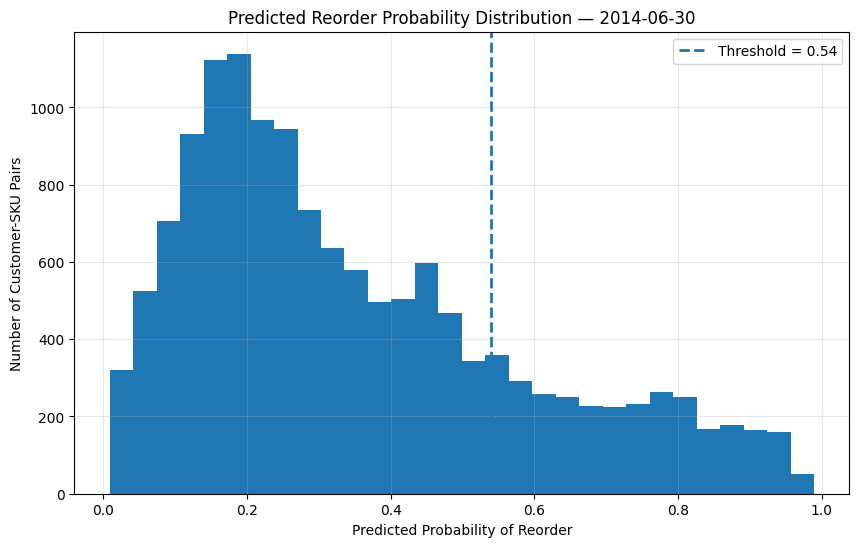

In [13]:
# PHASE 3 — CELL 10
# Distribution of predicted reorder probabilities

plt.figure(figsize=(10, 6))

plt.hist(
    latest_snapshot["reorder_probability"],
    bins=30
)

plt.axvline(
    metadata["threshold"],
    linestyle="--",
    linewidth=2,
    label=f"Threshold = {metadata['threshold']:.2f}"
)

plt.xlabel("Predicted Probability of Reorder")
plt.ylabel("Number of Customer-SKU Pairs")
plt.title(
    "Predicted Reorder Probability Distribution — 2014-06-30"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [14]:
# PHASE 3 — CELL 11
# Customer-level reorder opportunity summary

customer_opportunities = (
    reorder_opportunities
    .groupby("Member")
    .agg(
        sku_opportunities=("SKU", "count"),
        predicted_reorders=("predicted_reorder", "sum"),
        avg_reorder_probability=("reorder_probability", "mean"),
        max_reorder_probability=("reorder_probability", "max")
    )
    .reset_index()
)

customer_opportunities["reorder_opportunity_rate"] = (
    customer_opportunities["predicted_reorders"]
    / customer_opportunities["sku_opportunities"]
)

customer_opportunities = (
    customer_opportunities
    .sort_values(
        ["predicted_reorders", "avg_reorder_probability"],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)

print("Number of customers:", len(customer_opportunities))

print("\nTop customer-level reorder opportunities:")

display(
    customer_opportunities.head(20)
)

Number of customers: 106

Top customer-level reorder opportunities:


,Member,sku_opportunities,predicted_reorders,avg_reorder_probability,max_reorder_probability,reorder_opportunity_rate
0,M38622,230,65,0.40,0.96,0.28
1,M41747,120,51,0.48,0.96,0.42
2,M09736,105,49,0.56,0.98,0.47
3,M33064,224,49,0.33,0.95,0.22
4,M36432,208,47,0.37,0.93,0.23
5,M41781,230,46,0.32,0.96,0.20
6,M14746,154,45,0.41,0.99,0.29
7,M35649,169,44,0.39,0.90,0.26
8,M78365,98,42,0.49,0.96,0.43
9,M84827,125,41,0.42,0.98,0.33


In [15]:
# PHASE 3 — CELL 12
# Top customers by number of predicted reorder opportunities

top_customers = (
    customer_opportunities
    .sort_values(
        "predicted_reorders",
        ascending=False
    )
    .head(20)
)

display(top_customers)

,Member,sku_opportunities,predicted_reorders,avg_reorder_probability,max_reorder_probability,reorder_opportunity_rate
0,M38622,230,65,0.40,0.96,0.28
1,M41747,120,51,0.48,0.96,0.42
2,M09736,105,49,0.56,0.98,0.47
3,M33064,224,49,0.33,0.95,0.22
4,M36432,208,47,0.37,0.93,0.23
5,M41781,230,46,0.32,0.96,0.20
6,M14746,154,45,0.41,0.99,0.29
7,M35649,169,44,0.39,0.90,0.26
8,M78365,98,42,0.49,0.96,0.43
9,M84827,125,41,0.42,0.98,0.33


In [16]:
# PHASE 3 — CELL 13
# SKU-level reorder opportunity summary

sku_opportunities = (
    reorder_opportunities
    .groupby(["SKU", "Description"])
    .agg(
        customer_opportunities=("Member", "count"),
        predicted_reorders=("predicted_reorder", "sum"),
        avg_reorder_probability=("reorder_probability", "mean"),
        max_reorder_probability=("reorder_probability", "max")
    )
    .reset_index()
)

sku_opportunities["reorder_opportunity_rate"] = (
    sku_opportunities["predicted_reorders"]
    / sku_opportunities["customer_opportunities"]
)

sku_opportunities = (
    sku_opportunities
    .sort_values(
        ["predicted_reorders", "avg_reorder_probability"],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)

print("Number of SKUs:", len(sku_opportunities))

print("\nTop SKU-level reorder opportunities:")

display(
    sku_opportunities.head(20)
)

Number of SKUs: 1637

Top SKU-level reorder opportunities:


,SKU,Description,customer_opportunities,predicted_reorders,avg_reorder_probability,max_reorder_probability,reorder_opportunity_rate
0,15668381,Other Vegetables,99,84,0.75,0.96,0.85
1,15668688,Root Vegetables,103,78,0.69,0.96,0.76
2,15668379,Other Vegetables,98,72,0.67,0.95,0.73
3,15668460,Gourd & Cucumber,82,63,0.73,0.95,0.77
4,15668468,Beans,90,63,0.66,0.96,0.70
5,15668478,Banana,81,60,0.70,0.95,0.74
6,15668467,Beans,87,60,0.65,0.99,0.69
7,15668378,Other Vegetables,83,57,0.67,0.98,0.69
8,15668465,Root Vegetables,86,56,0.66,0.98,0.65
9,15668375,Root Vegetables,84,52,0.64,0.98,0.62


In [17]:
# PHASE 3 — CELL 14
# Top products by predicted reorder demand

top_skus = (
    sku_opportunities
    .sort_values(
        "predicted_reorders",
        ascending=False
    )
    .head(20)
)

display(top_skus)

,SKU,Description,customer_opportunities,predicted_reorders,avg_reorder_probability,max_reorder_probability,reorder_opportunity_rate
0,15668381,Other Vegetables,99,84,0.75,0.96,0.85
1,15668688,Root Vegetables,103,78,0.69,0.96,0.76
2,15668379,Other Vegetables,98,72,0.67,0.95,0.73
3,15668460,Gourd & Cucumber,82,63,0.73,0.95,0.77
4,15668468,Beans,90,63,0.66,0.96,0.70
6,15668467,Beans,87,60,0.65,0.99,0.69
5,15668478,Banana,81,60,0.70,0.95,0.74
7,15668378,Other Vegetables,83,57,0.67,0.98,0.69
8,15668465,Root Vegetables,86,56,0.66,0.98,0.65
10,15668462,Gourd & Cucumber,82,52,0.64,0.98,0.63


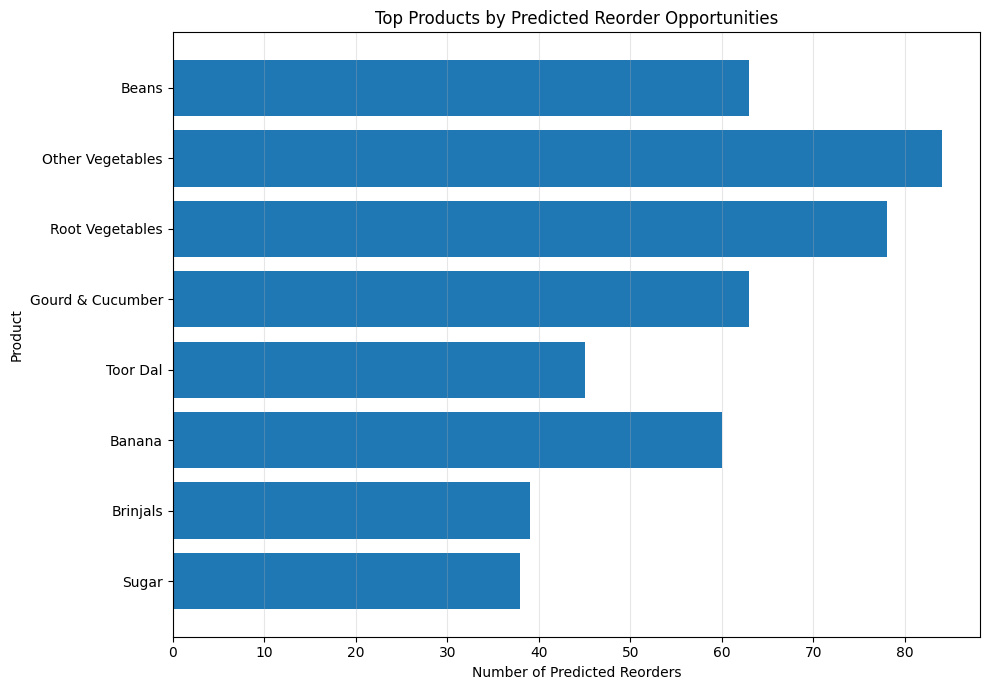

In [18]:
# PHASE 3 — CELL 15
# Top 15 SKUs by predicted reorder opportunities

plot_data = (
    sku_opportunities
    .head(15)
    .sort_values("predicted_reorders")
)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_data["Description"].astype(str),
    plot_data["predicted_reorders"]
)

plt.xlabel("Number of Predicted Reorders")
plt.ylabel("Product")
plt.title("Top Products by Predicted Reorder Opportunities")

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

In [19]:
# PHASE 3 — CELL 16 FIX
# Correctly match predictions to customer-SKU pairs

prediction_date = pd.Timestamp("2014-06-30")

evaluation_df = model_df[
    model_df["snapshot_date"] == prediction_date
].copy()

print("Evaluation snapshot:", prediction_date.date())
print("Rows:", len(evaluation_df))

# ---------------------------------------------------------
# IMPORTANT:
# Match predictions using Member + SKU, NOT dataframe order
# ---------------------------------------------------------

prediction_lookup = reorder_opportunities[
    ["Member", "SKU", "reorder_probability"]
].copy()

# Make sure each customer-SKU pair occurs only once
prediction_lookup = prediction_lookup.drop_duplicates(
    subset=["Member", "SKU"]
)

# Merge predictions onto the correct customer-SKU rows
evaluation_df = evaluation_df.merge(
    prediction_lookup,
    on=["Member", "SKU"],
    how="left"
)

# Customer-SKU pairs not predicted as reorder opportunities
# must have probability 0 / below threshold.
evaluation_df["reorder_probability"] = (
    evaluation_df["reorder_probability"]
    .fillna(0)
)

# Apply final threshold from Phase 2 metadata
final_threshold = metadata["threshold"]

evaluation_df["predicted_reorder"] = (
    evaluation_df["reorder_probability"] >= final_threshold
).astype(int)

print("\nFinal threshold:", final_threshold)

print("\nMissing probabilities:",
      evaluation_df["reorder_probability"].isna().sum())

print("\nActual target distribution:")
print(evaluation_df["target_reorder"].value_counts())

print("\nActual reorder rate:",
      evaluation_df["target_reorder"].mean() * 100)

print("\nPredicted distribution:")
print(evaluation_df["predicted_reorder"].value_counts())

print("\nPredicted reorder rate:",
      evaluation_df["predicted_reorder"].mean() * 100)

Evaluation snapshot: 2014-06-30
Rows: 14096

Final threshold: 0.5399999999999998

Missing probabilities: 0

Actual target distribution:
target_reorder
0    10980
1     3116
Name: count, dtype: int64

Actual reorder rate: 22.105561861520997

Predicted distribution:
predicted_reorder
0    11118
1     2978
Name: count, dtype: int64

Predicted reorder rate: 21.12656072644722


In [20]:
# PHASE 3 — CELL 16B
# Verify prediction matching

print("Evaluation rows:", len(evaluation_df))

print(
    "Rows with predictions:",
    evaluation_df["reorder_probability"].notna().sum()
)

print(
    "Predicted reorder opportunities:",
    evaluation_df["predicted_reorder"].sum()
)

print(
    "Expected predicted opportunities:",
    len(reorder_opportunities)
)

print(
    "Unique evaluation customer-SKU pairs:",
    evaluation_df[["Member", "SKU"]].drop_duplicates().shape[0]
)

print(
    "Unique prediction customer-SKU pairs:",
    prediction_lookup[["Member", "SKU"]].drop_duplicates().shape[0]
)

Evaluation rows: 14096
Rows with predictions: 14096
Predicted reorder opportunities: 2978
Expected predicted opportunities: 14096
Unique evaluation customer-SKU pairs: 14096
Unique prediction customer-SKU pairs: 14096


In [21]:
# PHASE 3 — CELL 17
# Correct final retrospective evaluation

from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

y_actual = evaluation_df["target_reorder"]
y_predicted = evaluation_df["predicted_reorder"]

cm = confusion_matrix(y_actual, y_predicted)

print("========================================")
print("FINAL RETROSPECTIVE EVALUATION")
print("========================================")

print("Threshold:", final_threshold)

print("\nAccuracy :", accuracy_score(y_actual, y_predicted))
print("Precision:", precision_score(y_actual, y_predicted))
print("Recall   :", recall_score(y_actual, y_predicted))
print("F1 Score :", f1_score(y_actual, y_predicted))

print("\nConfusion Matrix:")
print(cm)

tn, fp, fn, tp = cm.ravel()

print("\nTrue Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

FINAL RETROSPECTIVE EVALUATION
Threshold: 0.5399999999999998

Accuracy : 0.8196651532349603
Precision: 0.5963734049697784
Recall   : 0.5699614890885751
F1 Score : 0.5828683951427633

Confusion Matrix:
[[9778 1202]
 [1340 1776]]

True Negatives : 9778
False Positives: 1202
False Negatives: 1340
True Positives : 1776


In [22]:
# PHASE 3 — CELL 18
# Actual reorder rate among predicted opportunities

predicted_opportunities = evaluation_df[
    evaluation_df["predicted_reorder"] == 1
].copy()

actual_reorders_among_predictions = (
    predicted_opportunities["target_reorder"].sum()
)

total_predicted_opportunities = len(predicted_opportunities)

opportunity_precision = (
    actual_reorders_among_predictions
    / total_predicted_opportunities
)

print("Predicted reorder opportunities:",
      total_predicted_opportunities)

print("Actually reordered:",
      actual_reorders_among_predictions)

print(
    "Opportunity precision:",
    opportunity_precision * 100,
    "%"
)

Predicted reorder opportunities: 2978
Actually reordered: 1776
Opportunity precision: 59.63734049697784 %


In [23]:
# PHASE 3 — CELL 19
# Lift over random targeting

overall_reorder_rate = evaluation_df["target_reorder"].mean()

lift = opportunity_precision / overall_reorder_rate

print("Overall actual reorder rate:",
      overall_reorder_rate * 100, "%")

print("Predicted-opportunity precision:",
      opportunity_precision * 100, "%")

print("Lift over random targeting:",
      lift)

Overall actual reorder rate: 22.105561861520997 %
Predicted-opportunity precision: 59.63734049697784 %
Lift over random targeting: 2.697843233778561


In [24]:
# PHASE 3 — CELL 20 FIX

evaluation_df["probability_band"] = pd.cut(
    evaluation_df["reorder_probability"],
    bins=[0, 0.2, 0.4, 0.54, 0.6, 0.7, 0.8, 0.9, 1.0],
    include_lowest=True
)

probability_analysis = (
    evaluation_df
    .groupby("probability_band", observed=False)
    .agg(
        customer_sku_pairs=("target_reorder", "count"),
        actual_reorders=("target_reorder", "sum"),
        actual_reorder_rate=("target_reorder", "mean")
    )
    .reset_index()
)

probability_analysis["actual_reorder_rate"] *= 100

print(probability_analysis)

  probability_band  customer_sku_pairs  actual_reorders  actual_reorder_rate
0    (-0.001, 0.2]                4590              232                 5.05
1       (0.2, 0.4]                4503              580                12.88
2      (0.4, 0.54]                2025              528                26.07
3      (0.54, 0.6]                 580              223                38.45
4       (0.6, 0.7]                 739              359                48.58
5       (0.7, 0.8]                 734              447                60.90
6       (0.8, 0.9]                 588              444                75.51
7       (0.9, 1.0]                 337              303                89.91


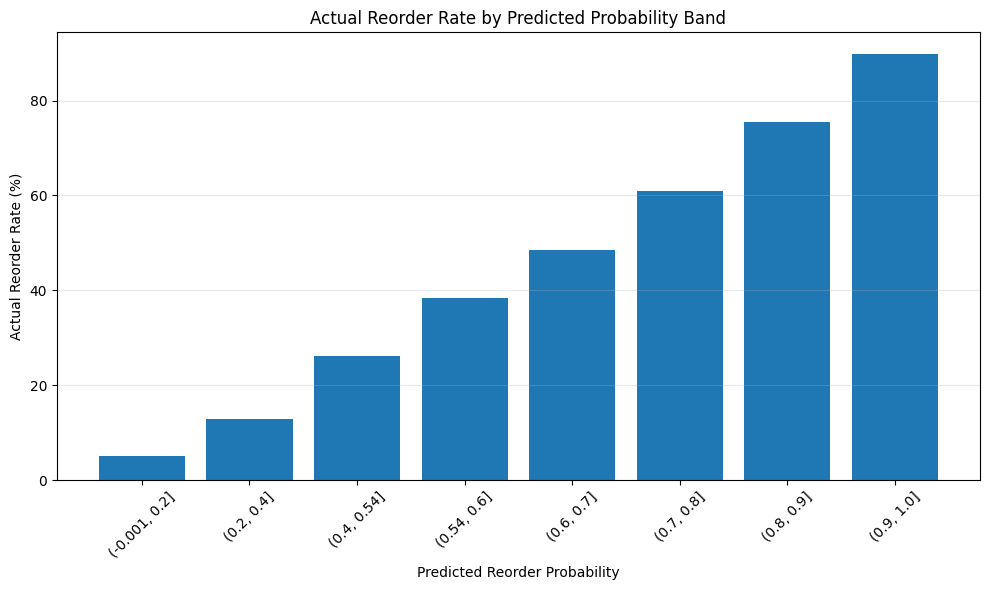

In [25]:
# PHASE 3 — CELL 21
# Actual reorder rate by predicted probability band

plt.figure(figsize=(10, 6))

plt.bar(
    probability_analysis["probability_band"].astype(str),
    probability_analysis["actual_reorder_rate"]
)

plt.xlabel("Predicted Reorder Probability")
plt.ylabel("Actual Reorder Rate (%)")
plt.title("Actual Reorder Rate by Predicted Probability Band")

plt.xticks(rotation=45)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [26]:
# ============================================================
# PHASE 3 — CELL 22
# FINAL MODEL SUMMARY
# ============================================================

final_summary = pd.DataFrame({
    "Metric": [
        "Model",
        "Prediction Snapshot",
        "Customer-SKU Pairs",
        "Predicted Reorder Opportunities",
        "Predicted Opportunity Rate (%)",
        "Actual Reorder Rate (%)",
        "Threshold",
        "Accuracy (%)",
        "Precision (%)",
        "Recall (%)",
        "F1 Score (%)",
        "ROC-AUC",
        "PR-AUC",
        "Opportunity Precision (%)",
        "Lift over Random Targeting"
    ],
    "Value": [
        "Random Forest",
        "2014-06-30",
        len(evaluation_df),
        int(evaluation_df["predicted_reorder"].sum()),
        evaluation_df["predicted_reorder"].mean() * 100,
        evaluation_df["target_reorder"].mean() * 100,
        final_threshold,
        accuracy_score(y_actual, y_predicted) * 100,
        precision_score(y_actual, y_predicted) * 100,
        recall_score(y_actual, y_predicted) * 100,
        f1_score(y_actual, y_predicted) * 100,
        0.8230,
        0.6247,
        opportunity_precision * 100,
        lift
    ]
})

print(final_summary.to_string(index=False))

                         Metric         Value
                          Model Random Forest
            Prediction Snapshot    2014-06-30
             Customer-SKU Pairs         14096
Predicted Reorder Opportunities          2978
 Predicted Opportunity Rate (%)         21.13
        Actual Reorder Rate (%)         22.11
                      Threshold          0.54
                   Accuracy (%)         81.97
                  Precision (%)         59.64
                     Recall (%)         57.00
                   F1 Score (%)         58.29
                        ROC-AUC          0.82
                         PR-AUC          0.62
      Opportunity Precision (%)         59.64
     Lift over Random Targeting          2.70


In [27]:
# ============================================================
# PHASE 3 — CELL 23
# FINAL CUSTOMER-SKU REORDER OPPORTUNITIES
# ============================================================

final_opportunities = evaluation_df[
    evaluation_df["predicted_reorder"] == 1
].copy()

final_opportunities = final_opportunities.sort_values(
    "reorder_probability",
    ascending=False
)

opportunity_columns = [
    "Member",
    "SKU",
    "Description",
    "purchase_count",
    "reorder_count",
    "is_repeat",
    "recency_days",
    "total_orders",
    "avg_basket_size",
    "customer_lifetime_days",
    "sku_total_purchases",
    "sku_unique_customers",
    "reorder_probability",
    "predicted_reorder"
]

final_opportunities = final_opportunities[
    opportunity_columns
].reset_index(drop=True)

print("Final reorder opportunities:",
      len(final_opportunities))

print("\nTop 20 highest-probability opportunities:")
display(final_opportunities.head(20))

Final reorder opportunities: 2978

Top 20 highest-probability opportunities:


,Member,SKU,Description,purchase_count,reorder_count,is_repeat,recency_days,total_orders,avg_basket_size,customer_lifetime_days,sku_total_purchases,sku_unique_customers,reorder_probability,predicted_reorder
0,M39021,7580802,Sunflower Oils,31,30,True,0.31,37,8.73,535.90,163,21,0.99,1
1,M27458,15668467,Beans,23,22,True,4.64,64,6.25,529.60,841,87,0.99,1
2,M14746,15668451,Brinjals,18,17,True,3.68,55,9.53,539.49,570,75,0.99,1
3,M91098,15668451,Brinjals,19,18,True,7.19,47,7.91,527.16,570,75,0.99,1
4,M64055,15668416,Banana,32,31,True,4.37,46,10.02,546.00,825,72,0.98,1
5,M77779,15668462,Gourd & Cucumber,25,24,True,1.49,38,10.34,533.82,782,82,0.98,1
6,M27458,15668465,Root Vegetables,18,17,True,4.64,64,6.25,529.60,792,86,0.98,1
7,M09736,15669856,Sugar,13,12,True,7.48,37,10.70,350.38,424,73,0.98,1
8,M39021,15668375,Root Vegetables,11,10,True,0.31,37,8.73,535.90,436,84,0.98,1
9,M47229,15668378,Other Vegetables,13,12,True,2.35,31,11.10,413.33,845,83,0.98,1


In [28]:
# ============================================================
# PHASE 3 — CELL 24
# CUSTOMER-LEVEL REORDER OPPORTUNITIES
# ============================================================

customer_opportunities = (
    final_opportunities
    .groupby("Member")
    .agg(
        sku_opportunities=("SKU", "count"),
        avg_reorder_probability=("reorder_probability", "mean"),
        max_reorder_probability=("reorder_probability", "max")
    )
    .reset_index()
)

customer_opportunities["opportunity_rate"] = (
    customer_opportunities["sku_opportunities"]
    / evaluation_df.groupby("Member")["SKU"].count()
    .reindex(customer_opportunities["Member"])
    .values
)

customer_opportunities = customer_opportunities.sort_values(
    ["sku_opportunities", "avg_reorder_probability"],
    ascending=False
)

print("Top customers by predicted reorder opportunities:")
display(customer_opportunities.head(20))

Top customers by predicted reorder opportunities:


,Member,sku_opportunities,avg_reorder_probability,max_reorder_probability,opportunity_rate
38,M38622,65,0.74,0.96,0.28
42,M41747,51,0.74,0.96,0.42
3,M09736,49,0.80,0.98,0.47
22,M33064,49,0.75,0.95,0.22
33,M36432,47,0.72,0.93,0.23
43,M41781,46,0.69,0.96,0.20
6,M14746,45,0.73,0.99,0.29
31,M35649,44,0.71,0.90,0.26
94,M78365,42,0.73,0.96,0.43
97,M84827,41,0.73,0.98,0.33


In [29]:
# ============================================================
# PHASE 3 — CELL 25
# PRODUCT/SKU-LEVEL REORDER OPPORTUNITIES
# ============================================================

product_opportunities = (
    final_opportunities
    .groupby(["SKU", "Description"])
    .agg(
        predicted_reorders=("SKU", "count"),
        avg_reorder_probability=("reorder_probability", "mean"),
        max_reorder_probability=("reorder_probability", "max")
    )
    .reset_index()
)

product_opportunities = product_opportunities.sort_values(
    ["predicted_reorders", "avg_reorder_probability"],
    ascending=False
)

print("Top products by predicted reorder opportunities:")
display(product_opportunities.head(20))

Top products by predicted reorder opportunities:


,SKU,Description,predicted_reorders,avg_reorder_probability,max_reorder_probability
195,15668381,Other Vegetables,84,0.80,0.96
236,15668688,Root Vegetables,78,0.77,0.96
193,15668379,Other Vegetables,72,0.76,0.95
205,15668460,Gourd & Cucumber,63,0.82,0.95
211,15668468,Beans,63,0.76,0.96
221,15668478,Banana,60,0.80,0.95
210,15668467,Beans,60,0.75,0.99
192,15668378,Other Vegetables,57,0.79,0.98
208,15668465,Root Vegetables,56,0.78,0.98
190,15668375,Root Vegetables,52,0.77,0.98


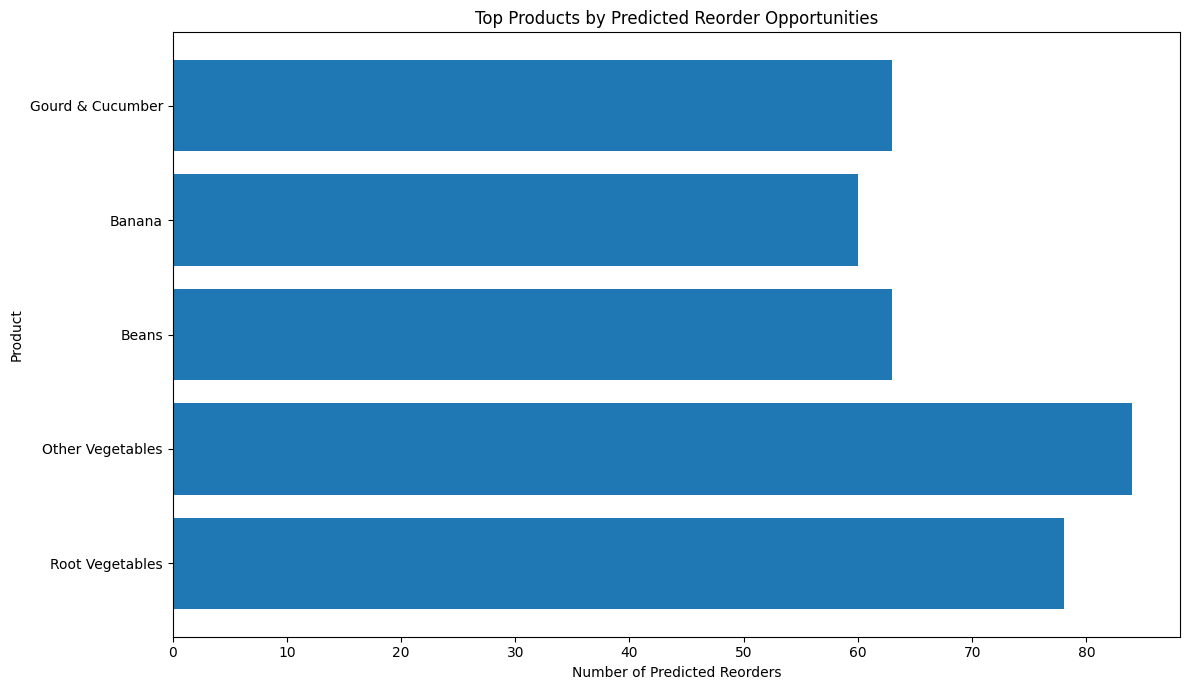

In [30]:
# ============================================================
# PHASE 3 — CELL 26
# FINAL BUSINESS VISUALIZATION
# ============================================================

top_products = product_opportunities.head(10).copy()

plt.figure(figsize=(12, 7))

plt.barh(
    top_products["Description"].astype(str)[::-1],
    top_products["predicted_reorders"][::-1]
)

plt.xlabel("Number of Predicted Reorders")
plt.ylabel("Product")
plt.title("Top Products by Predicted Reorder Opportunities")

plt.tight_layout()
plt.show()

In [31]:
# ============================================================
# PHASE 3 — CELL 27
# SAVE FINAL PHASE 3 OUTPUTS
# ============================================================

final_opportunities.to_csv(
    "/content/drive/MyDrive/final_customer_sku_reorder_opportunities.csv",
    index=False
)

customer_opportunities.to_csv(
    "/content/drive/MyDrive/customer_reorder_opportunities.csv",
    index=False
)

product_opportunities.to_csv(
    "/content/drive/MyDrive/product_reorder_opportunities.csv",
    index=False
)

final_summary.to_csv(
    "/content/drive/MyDrive/final_model_summary.csv",
    index=False
)

print("Phase 3 outputs saved successfully.")

Phase 3 outputs saved successfully.


In [32]:
print("Available DataFrames:")
for name, obj in globals().items():
    if hasattr(obj, "shape") and hasattr(obj, "columns"):
        print(f"{name}: {obj.shape}")

Available DataFrames:
df: (62141, 10)
model_df: (56881, 25)
latest_snapshot: (14096, 27)
X_latest: (14096, 16)
reorder_opportunities: (14096, 16)
predicted_reorders: (2978, 16)
customer_opportunities: (105, 5)
top_customers: (20, 6)
sku_opportunities: (1637, 7)
top_skus: (20, 7)
plot_data: (15, 7)
evaluation_df: (14096, 28)
prediction_lookup: (14096, 3)
predicted_opportunities: (2978, 27)
probability_analysis: (8, 4)
final_summary: (15, 2)
final_opportunities: (2978, 14)
product_opportunities: (504, 5)
top_products: (10, 5)


In [33]:
print("evaluation_df columns:")
for i, col in enumerate(evaluation_df.columns):
    print(i, ":", col)

print("\nShape:", evaluation_df.shape)

print("\nFirst 3 rows:")
display(evaluation_df.head(3))

evaluation_df columns:
0 : Member
1 : SKU
2 : Description
3 : purchase_count
4 : first_purchase
5 : last_purchase
6 : avg_reorder_interval
7 : median_reorder_interval
8 : min_reorder_interval
9 : max_reorder_interval
10 : reorder_count
11 : is_repeat
12 : recency_days
13 : total_orders
14 : avg_basket_size
15 : median_basket_size
16 : customer_first_purchase
17 : customer_last_purchase
18 : customer_lifetime_days
19 : sku_total_purchases
20 : sku_total_orders
21 : sku_unique_customers
22 : sku_customer_penetration
23 : target_reorder
24 : snapshot_date
25 : reorder_probability
26 : predicted_reorder
27 : probability_band

Shape: (14096, 28)

First 3 rows:


,Member,SKU,Description,purchase_count,first_purchase,last_purchase,avg_reorder_interval,median_reorder_interval,min_reorder_interval,max_reorder_interval,reorder_count,is_repeat,recency_days,total_orders,avg_basket_size,median_basket_size,customer_first_purchase,customer_last_purchase,customer_lifetime_days,sku_total_purchases,sku_total_orders,sku_unique_customers,sku_customer_penetration,target_reorder,snapshot_date,reorder_probability,predicted_reorder,probability_band
0,M04158,7537167,Honey,1,2013-12-17 23:03:00.288000267,2013-12-17 23:03:00.288000267,NaN,NaN,NaN,NaN,0,False,194.04,122,3.81,4.00,2012-04-12 20:09:00,2014-06-26 14:26:00.096000293,804.76,6,6,5,4.72,0,2014-06-30,0.09,0,"(-0.001, 0.2]"
1,M04158,7537178,Honey,1,2013-11-21 18:44:00.383999930,2013-11-21 18:44:00.383999930,NaN,NaN,NaN,NaN,0,False,220.22,122,3.81,4.00,2012-04-12 20:09:00,2014-06-26 14:26:00.096000293,804.76,4,4,4,3.77,0,2014-06-30,0.10,0,"(-0.001, 0.2]"
2,M04158,7540256,Basmati Rice,2,2013-06-04 23:40:00.000000000,2014-02-06 12:01:00.000000000,246.51,246.51,246.51,246.51,1,True,143.50,122,3.81,4.00,2012-04-12 20:09:00,2014-06-26 14:26:00.096000293,804.76,4,4,3,2.83,0,2014-06-30,0.36,0,"(0.2, 0.4]"


In [34]:
# ============================================
# POWER BI EXPORT — PHASE 3 EVALUATION
# ============================================

import os

export_dir = "/content/drive/MyDrive/reorder_powerbi"
os.makedirs(export_dir, exist_ok=True)

# Main 14,096-row evaluation table
evaluation_df.to_csv(
    os.path.join(export_dir, "phase3_full_evaluation.csv"),
    index=False
)

print("Exported:")
print(os.path.join(export_dir, "phase3_full_evaluation.csv"))
print("Shape:", evaluation_df.shape)

Exported:
/content/drive/MyDrive/reorder_powerbi/phase3_full_evaluation.csv
Shape: (14096, 28)


In [35]:
# ============================================
# EXPORT PROBABILITY BAND ANALYSIS
# ============================================

probability_analysis.to_csv(
    os.path.join(export_dir, "probability_bands.csv"),
    index=False
)

print("Exported:")
print(os.path.join(export_dir, "probability_bands.csv"))
print("Shape:", probability_analysis.shape)

Exported:
/content/drive/MyDrive/reorder_powerbi/probability_bands.csv
Shape: (8, 4)
